In [1]:
import sys
import os
import math
sys.path.append("../")
sys.path.append("../..")

In [2]:
from scale_rl.common.wandb_utils import *

In [3]:
td7_eval_df = pd.read_csv('../../results/td7.csv', index_col=0)
sac_simba_eval_df = pd.read_csv('../../results/sac_simba.csv', index_col=0)
tdmpc2_eval_df = pd.read_csv('../../results/tdmpc2.csv', index_col=0)
dreamer3_eval_df = pd.read_csv('../../results/dreamerv3.csv', index_col=0)

#### Collection

In [4]:
off_policy_df = pd.concat([
    td7_eval_df,
    sac_simba_eval_df, 
    tdmpc2_eval_df,
    dreamer3_eval_df,
    ], ignore_index=True, sort=False)
off_policy_df['env_name'] = off_policy_df['env_name'].str.replace('_', '-')
off_policy_df

,exp_name,env_name,seed,metric,env_step,value
0,TD7,acrobot-swingup,1,avg_return,25000.0,2.128031
1,TD7,acrobot-swingup,1,avg_return,50000.0,0.077322
2,TD7,acrobot-swingup,1,avg_return,75000.0,30.068576
3,TD7,acrobot-swingup,1,avg_return,100000.0,69.333976
4,TD7,acrobot-swingup,1,avg_return,125000.0,46.783220
...,...,...,...,...,...,...
53631,dreamerv3,walker-walk,3,avg_return,300000.0,925.014982
53632,dreamerv3,walker-walk,3,avg_return,350000.0,936.634629
53633,dreamerv3,walker-walk,3,avg_return,400000.0,792.896831
53634,dreamerv3,walker-walk,3,avg_return,450000.0,938.021900


In [5]:
exp_names = off_policy_df['exp_name'].unique()
exp_names

array(['TD7', 'sac_simba', 'td_mpcv2', 'dreamerv3'], dtype=object)

In [6]:
env_names = off_policy_df['env_name'].unique()
env_names

array(['acrobot-swingup', 'cartpole-balance', 'cartpole-balance-sparse',
       'cartpole-swingup', 'cartpole-swingup-sparse', 'cheetah-run',
       'dog-run', 'dog-stand', 'dog-trot', 'dog-walk', 'finger-spin',
       'finger-turn-easy', 'finger-turn-hard', 'fish-swim',
       'h1-balance-hard-v0', 'h1-balance-simple-v0', 'h1-crawl-v0',
       'h1-hurdle-v0', 'h1-maze-v0', 'h1-pole-v0', 'h1-reach-v0',
       'h1-run-v0', 'h1-sit-hard-v0', 'h1-sit-simple-v0', 'h1-slide-v0',
       'h1-stair-v0', 'h1-stand-v0', 'h1-walk-v0', 'hopper-hop',
       'hopper-stand', 'humanoid-run', 'humanoid-stand', 'humanoid-walk',
       'myo-key-turn', 'myo-key-turn-hard', 'myo-obj-hold',
       'myo-obj-hold-hard', 'myo-pen-twirl', 'myo-pen-twirl-hard',
       'myo-pose', 'myo-pose-hard', 'myo-reach', 'myo-reach-hard',
       'pendulum-swingup', 'quadruped-run', 'quadruped-walk',
       'reacher-easy', 'reacher-hard', 'walker-run', 'walker-stand',
       'walker-walk', 'cheetah-jump', 'cheetah-run-back',

### Visualization

In [7]:
from rliable import library as rly
from rliable import metrics as rly_metrics
from rliable import plot_utils as rly_plot_utils

aggregate_func = lambda x: np.array([
  rly_metrics.aggregate_iqm(x),
  rly_metrics.aggregate_median(x),
  rly_metrics.aggregate_mean(x),
  rly_metrics.aggregate_optimality_gap(x/1000)])

In [8]:
from scale_rl.envs.dmc import DMC_EASY_MEDIUM, DMC_HARD
from scale_rl.envs.humanoid_bench import HB_LOCOMOTION_NOHAND, HB_SUCCESS_SCORE
from scale_rl.envs.myosuite import MYOSUITE_TASKS

def replace_hypen_to_underbar(env_name_list):
    for idx in range(len(env_name_list)):
        env_name_list[idx] = env_name_list[idx].replace('_', '-')
    return env_name_list

DMC_EASY_MEDIUM = replace_hypen_to_underbar(DMC_EASY_MEDIUM)
DMC_HARD = replace_hypen_to_underbar(DMC_HARD)
HB_LOCOMOTION_NOHAND = replace_hypen_to_underbar(HB_LOCOMOTION_NOHAND)
MYOSUITE_TASKS = replace_hypen_to_underbar(MYOSUITE_TASKS)

/home/nas4_user/youngdolee/anaconda3/envs/rl_playground/lib/python3.9/site-packages/glfw/__init__.py:916: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)


In [9]:
DMC_STEPS = 1000000 # 1M
MYO_STEPS = 1000000 # 1M
HB_STEPS = 2000000 # 2M

In [18]:
def full_results_per_env(
    eval_df,
    total_env_steps,
    aggregate_func,
    metric: str = "avg_return",
):
    experiments = eval_df["exp_name"].unique()
    environments = eval_df["env_name"].unique()
    
    metric_matrix_dict = generate_metric_matrix_dict(
        eval_df, 
        env_step=total_env_steps, 
        metric_type=metric,
    )
    aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(
        metric_matrix_dict, aggregate_func, reps=10000
    )
    
    eval_df = eval_df[eval_df["metric"] == metric]
    eval_df = eval_df[eval_df["env_step"] <= total_env_steps]
    
    full_results_df = pd.DataFrame(columns=["Task", "TD7", "Simba", "TD-MPC2", "DreamerV3"])
    
    for _exp_name in experiments:
        _exp_data = eval_df[eval_df["exp_name"] == _exp_name]
        _num_seeds = _exp_data["seed"].nunique()
        print(f"exp_name: {_exp_name} - num_seeds: {_num_seeds}")
        
    for i, env in enumerate(environments):
        mean_ci = []
        env_data = eval_df[eval_df["env_name"] == env]
        for j, exp in enumerate(experiments):
            exp_data = env_data[env_data["exp_name"] == exp]
            if len(exp_data) == 0:
                continue
            assert max(exp_data["env_step"]) == total_env_steps
            exp_data = exp_data[exp_data["env_step"] == total_env_steps]
            num_seeds = exp_data["seed"].nunique()
            
            grouped_data = exp_data.groupby("env_step")["value"]

            env_steps = grouped_data.mean().index.values
            mean = float(grouped_data.mean().values)
            std_dev = float(grouped_data.std().values)

            # Plot mean history
            low_CI = mean - 1.960 * std_dev / math.sqrt(num_seeds)
            high_CI = mean + 1.960 * std_dev / math.sqrt(num_seeds)
            
            if metric == "avg_success":
                mean, low_CI, high_CI = round(mean * 100.0, 1), round(low_CI * 100.0, 1), round(high_CI * 100.0, 1)
            else:    
                mean, low_CI, high_CI = int(mean), int(low_CI), int(high_CI)
            mean_ci.append(f"{mean}" + " \\textcolor{gray}{[" + f"{low_CI}, {high_CI}]" + "}")
        full_results_df = pd.concat([full_results_df, pd.DataFrame.from_dict(
                                data=[{"Task": "\\texttt{" + str(env) + "}",
                                "TD7": mean_ci[0],
                                "Simba": mean_ci[1],
                                "TD-MPC2": mean_ci[2],
                                "DreamerV3": mean_ci[3],
                                }], orient='columns')], ignore_index=True)

    
    for i, agg in enumerate(["IQM", "Median", "Mean", "Optimality Gap"]):
        mean_ci = []
        for j, exp in enumerate(experiments):
            mean = aggregate_scores[exp][i] 
            low_CI = aggregate_score_cis[exp][0][i] 
            high_CI = aggregate_score_cis[exp][1][i]

            if metric == "avg_success":
                mean, low_CI, high_CI = round(mean * 100.0, 1), round(low_CI * 100.0, 1), round(high_CI * 100.0, 1)
            else:    
                mean, low_CI, high_CI = int(mean), int(low_CI), int(high_CI)
            
            mean_ci.append(f"{mean}" + " \\textcolor{gray}{[" + f"{low_CI}, {high_CI}]" + "}")
        
        full_results_df = pd.concat([full_results_df, pd.DataFrame.from_dict(
                            data=[{"Task": agg,
                            "TD7": mean_ci[0],
                            "Simba": mean_ci[1],
                            "TD-MPC2": mean_ci[2],
                            "DreamerV3": mean_ci[3],
                            }], orient='columns')], ignore_index=True)

    return full_results_df
        

#### DMC

In [11]:
dmc_hard_eval_df = off_policy_df[off_policy_df['env_name'].isin(DMC_HARD)]
dmc_hard_full_results_df = full_results_per_env(
    dmc_hard_eval_df,
    total_env_steps=DMC_STEPS,
    aggregate_func=aggregate_func,
)
dmc_hard_full_results_df

exp_name: TD7 - num_seeds: 5
exp_name: sac_simba - num_seeds: 15
exp_name: td_mpcv2 - num_seeds: 3
exp_name: dreamerv3 - num_seeds: 3


,Task,TD7,Simba,TD-MPC2,DreamerV3
0,\texttt{dog-run},"127 \textcolor{gray}{[77, 177]}","544 \textcolor{gray}{[525, 564]}","169 \textcolor{gray}{[29, 309]}","15 \textcolor{gray}{[5, 25]}"
1,\texttt{dog-stand},"753 \textcolor{gray}{[666, 840]}","960 \textcolor{gray}{[951, 969]}","798 \textcolor{gray}{[766, 831]}","55 \textcolor{gray}{[34, 77]}"
2,\texttt{dog-trot},"125 \textcolor{gray}{[43, 208]}","824 \textcolor{gray}{[773, 876]}","500 \textcolor{gray}{[481, 518]}","10 \textcolor{gray}{[6, 14]}"
3,\texttt{dog-walk},"280 \textcolor{gray}{[28, 532]}","916 \textcolor{gray}{[905, 928]}","493 \textcolor{gray}{[62, 925]}","23 \textcolor{gray}{[10, 35]}"
4,\texttt{humanoid-run},"79 \textcolor{gray}{[16, 142]}","181 \textcolor{gray}{[171, 191]}","184 \textcolor{gray}{[157, 211]}","0 \textcolor{gray}{[0, 1]}"
5,\texttt{humanoid-stand},"389 \textcolor{gray}{[65, 713]}","846 \textcolor{gray}{[801, 890]}","663 \textcolor{gray}{[626, 700]}","5 \textcolor{gray}{[2, 7]}"
6,\texttt{humanoid-walk},"252 \textcolor{gray}{[43, 462]}","668 \textcolor{gray}{[608, 728]}","628 \textcolor{gray}{[609, 646]}","1 \textcolor{gray}{[0, 1]}"
7,IQM,"216 \textcolor{gray}{[112, 352]}","773 \textcolor{gray}{[712, 830]}","527 \textcolor{gray}{[367, 652]}","9 \textcolor{gray}{[4, 18]}"
8,Median,"272 \textcolor{gray}{[162, 397]}","706 \textcolor{gray}{[645, 773]}","528 \textcolor{gray}{[371, 626]}","17 \textcolor{gray}{[6, 26]}"
9,Mean,"287 \textcolor{gray}{[199, 379]}","706 \textcolor{gray}{[655, 754]}","491 \textcolor{gray}{[386, 595]}","16 \textcolor{gray}{[8, 24]}"


In [12]:
dmc_hard_latex_df = dmc_hard_full_results_df.to_latex(index=False)
dmc_hard_latex_df

'\\begin{tabular}{lllll}\n\\toprule\nTask & TD7 & Simba & TD-MPC2 & DreamerV3 \\\\\n\\midrule\n\\texttt{dog-run} & 127 \\textcolor{gray}{[77, 177]} & 544 \\textcolor{gray}{[525, 564]} & 169 \\textcolor{gray}{[29, 309]} & 15 \\textcolor{gray}{[5, 25]} \\\\\n\\texttt{dog-stand} & 753 \\textcolor{gray}{[666, 840]} & 960 \\textcolor{gray}{[951, 969]} & 798 \\textcolor{gray}{[766, 831]} & 55 \\textcolor{gray}{[34, 77]} \\\\\n\\texttt{dog-trot} & 125 \\textcolor{gray}{[43, 208]} & 824 \\textcolor{gray}{[773, 876]} & 500 \\textcolor{gray}{[481, 518]} & 10 \\textcolor{gray}{[6, 14]} \\\\\n\\texttt{dog-walk} & 280 \\textcolor{gray}{[28, 532]} & 916 \\textcolor{gray}{[905, 928]} & 493 \\textcolor{gray}{[62, 925]} & 23 \\textcolor{gray}{[10, 35]} \\\\\n\\texttt{humanoid-run} & 79 \\textcolor{gray}{[16, 142]} & 181 \\textcolor{gray}{[171, 191]} & 184 \\textcolor{gray}{[157, 211]} & 0 \\textcolor{gray}{[0, 1]} \\\\\n\\texttt{humanoid-stand} & 389 \\textcolor{gray}{[65, 713]} & 846 \\textcolor{gray}

In [13]:
with open('dmc_results.tex', 'w') as tf:
    tf.write(dmc_hard_latex_df)

#### MyoSuite

In [19]:
myosuite_eval_df = off_policy_df[off_policy_df['env_name'].isin(MYOSUITE_TASKS)]
myosuite_full_results_df = full_results_per_env(
    myosuite_eval_df,
    total_env_steps=MYO_STEPS,
    aggregate_func=aggregate_func,
    metric="avg_success"
)
myosuite_full_results_df

exp_name: TD7 - num_seeds: 5
exp_name: sac_simba - num_seeds: 10
exp_name: td_mpcv2 - num_seeds: 3
exp_name: dreamerv3 - num_seeds: 3


,Task,TD7,Simba,TD-MPC2,DreamerV3
0,\texttt{myo-key-turn},"100.0 \textcolor{gray}{[100.0, 100.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}","88.9 \textcolor{gray}{[67.1, 110.7]}"
1,\texttt{myo-key-turn-hard},"0.0 \textcolor{gray}{[0.0, 0.0]}","7.0 \textcolor{gray}{[-3.1, 17.1]}","0.0 \textcolor{gray}{[0.0, 0.0]}","0.0 \textcolor{gray}{[0.0, 0.0]}"
2,\texttt{myo-obj-hold},"20.0 \textcolor{gray}{[-19.2, 59.2]}","90.0 \textcolor{gray}{[70.4, 109.6]}","100.0 \textcolor{gray}{[100.0, 100.0]}","33.3 \textcolor{gray}{[-32.0, 98.7]}"
3,\texttt{myo-obj-hold-hard},"10.0 \textcolor{gray}{[-0.7, 20.7]}","96.0 \textcolor{gray}{[92.8, 99.2]}","56.7 \textcolor{gray}{[39.4, 74.0]}","9.4 \textcolor{gray}{[8.4, 10.5]}"
4,\texttt{myo-pen-twirl},"100.0 \textcolor{gray}{[100.0, 100.0]}","80.0 \textcolor{gray}{[53.9, 106.1]}","70.0 \textcolor{gray}{[11.2, 128.8]}","96.7 \textcolor{gray}{[90.1, 103.2]}"
5,\texttt{myo-pen-twirl-hard},"12.0 \textcolor{gray}{[2.4, 21.6]}","77.0 \textcolor{gray}{[66.4, 87.6]}","40.0 \textcolor{gray}{[40.0, 40.0]}","53.3 \textcolor{gray}{[29.8, 76.9]}"
6,\texttt{myo-pose},"0.0 \textcolor{gray}{[0.0, 0.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}"
7,\texttt{myo-pose-hard},"0.0 \textcolor{gray}{[0.0, 0.0]}","0.0 \textcolor{gray}{[0.0, 0.0]}","0.0 \textcolor{gray}{[0.0, 0.0]}","0.0 \textcolor{gray}{[0.0, 0.0]}"
8,\texttt{myo-reach},"100.0 \textcolor{gray}{[100.0, 100.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}","100.0 \textcolor{gray}{[100.0, 100.0]}"
9,\texttt{myo-reach-hard},"14.0 \textcolor{gray}{[0.7, 27.3]}","93.0 \textcolor{gray}{[86.4, 99.6]}","83.3 \textcolor{gray}{[66.0, 100.6]}","0.0 \textcolor{gray}{[0.0, 0.0]}"


In [20]:
myosuite_latex_df = myosuite_full_results_df.to_latex(index=False)
myosuite_latex_df

'\\begin{tabular}{lllll}\n\\toprule\nTask & TD7 & Simba & TD-MPC2 & DreamerV3 \\\\\n\\midrule\n\\texttt{myo-key-turn} & 100.0 \\textcolor{gray}{[100.0, 100.0]} & 100.0 \\textcolor{gray}{[100.0, 100.0]} & 100.0 \\textcolor{gray}{[100.0, 100.0]} & 88.9 \\textcolor{gray}{[67.1, 110.7]} \\\\\n\\texttt{myo-key-turn-hard} & 0.0 \\textcolor{gray}{[0.0, 0.0]} & 7.0 \\textcolor{gray}{[-3.1, 17.1]} & 0.0 \\textcolor{gray}{[0.0, 0.0]} & 0.0 \\textcolor{gray}{[0.0, 0.0]} \\\\\n\\texttt{myo-obj-hold} & 20.0 \\textcolor{gray}{[-19.2, 59.2]} & 90.0 \\textcolor{gray}{[70.4, 109.6]} & 100.0 \\textcolor{gray}{[100.0, 100.0]} & 33.3 \\textcolor{gray}{[-32.0, 98.7]} \\\\\n\\texttt{myo-obj-hold-hard} & 10.0 \\textcolor{gray}{[-0.7, 20.7]} & 96.0 \\textcolor{gray}{[92.8, 99.2]} & 56.7 \\textcolor{gray}{[39.4, 74.0]} & 9.4 \\textcolor{gray}{[8.4, 10.5]} \\\\\n\\texttt{myo-pen-twirl} & 100.0 \\textcolor{gray}{[100.0, 100.0]} & 80.0 \\textcolor{gray}{[53.9, 106.1]} & 70.0 \\textcolor{gray}{[11.2, 128.8]} & 96.

In [21]:
with open('myosuite_results.tex', 'w') as tf:
    tf.write(myosuite_latex_df)

#### Humanoid Bench

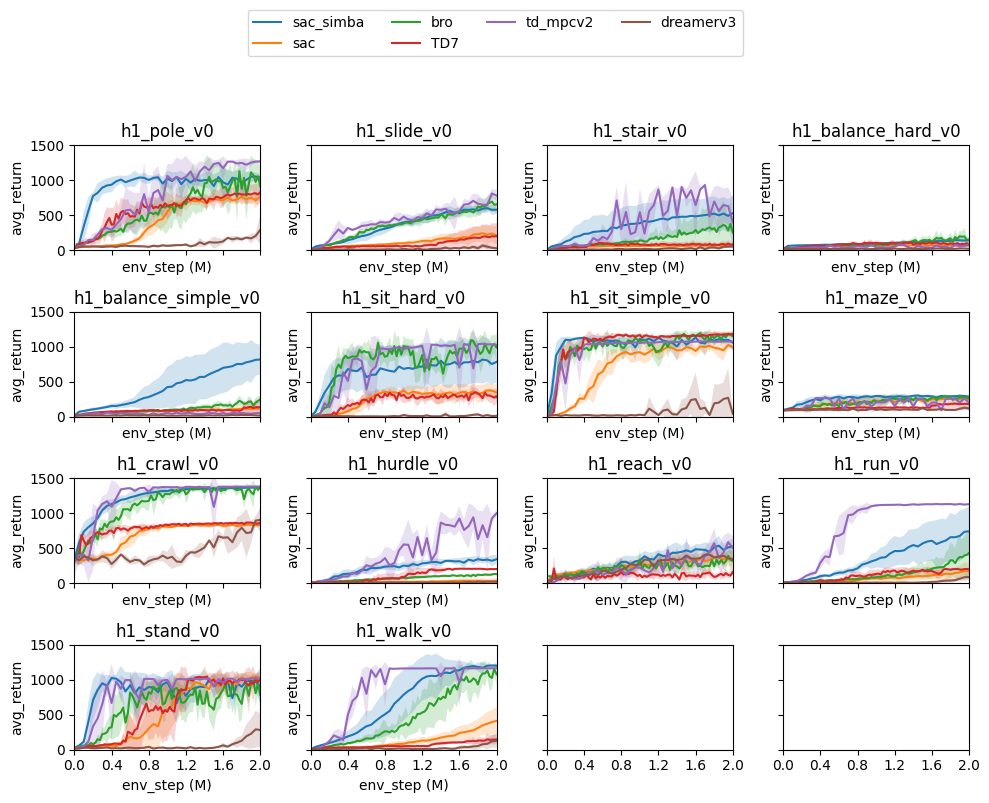

In [65]:
hb_eval_df = off_policy_df[off_policy_df['env_name'].isin(HB_LOCOMOTION_NOHAND)]
hb_eval_df = normalize_values(hb_eval_df, TASK_SUCCESS_SCORE)
plot_metric_history_per_env(
    hb_eval_df, 
    plot_height = 7, 
    num_plots_per_row=4,
    x_lim_max = 2e6,
    y_lim_max = 1500,
)

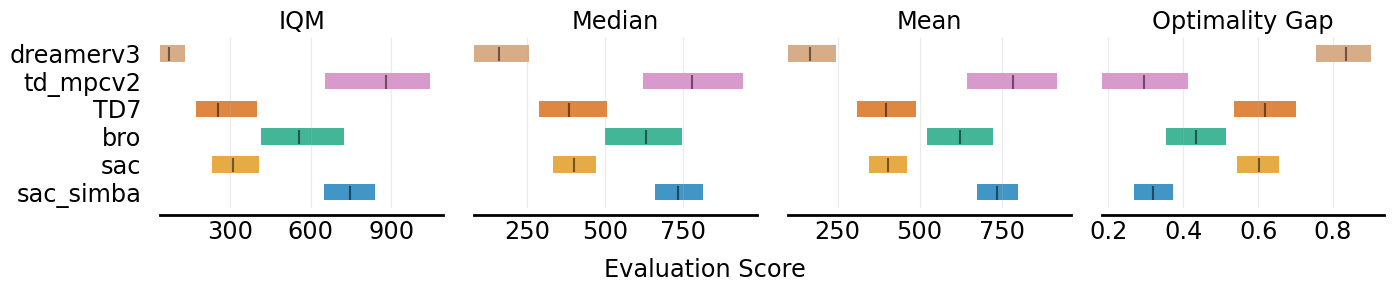

In [66]:
hb_metric_matrix_dict = generate_metric_matrix_dict(hb_eval_df, env_step=2_000_000, metric_type='avg_return')
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(
  hb_metric_matrix_dict, aggregate_func, reps=10000)

fig, axes = rly_plot_utils.plot_interval_estimates(
  aggregate_scores, aggregate_score_cis,
  metric_names=['IQM', 'Median', 'Mean', 'Optimality Gap'],
  algorithms=['sac_simba', 'sac', 'bro', 'TD7', 'td_mpcv2', 'dreamerv3'],
  xlabel_y_coordinate=-0.2,
  xlabel='Evaluation Score',
)

#### Myosuite

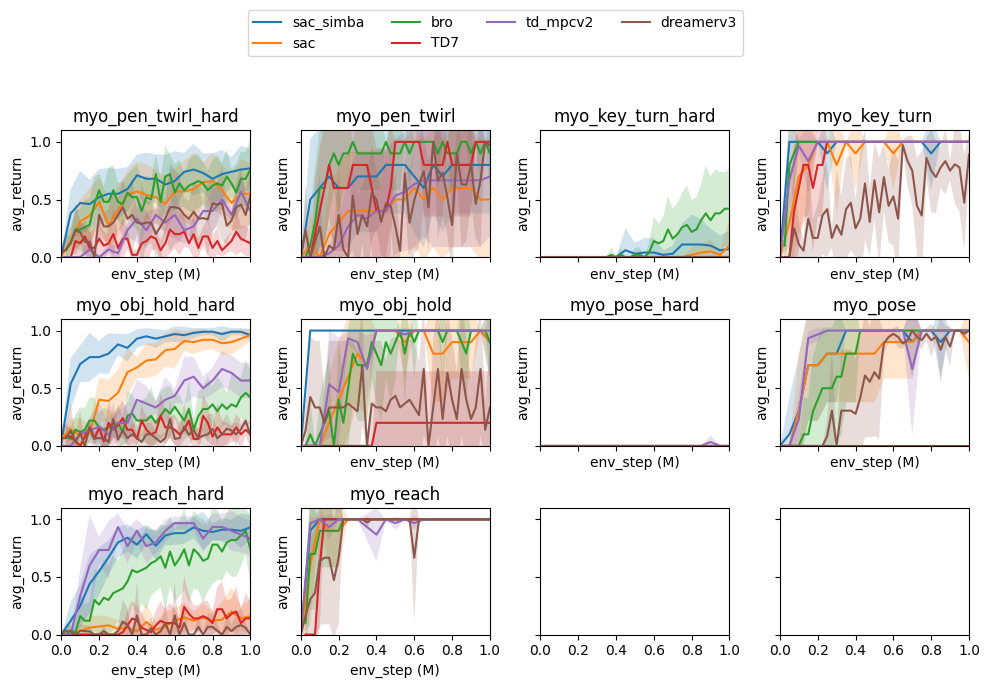

In [67]:
myo_eval_df = off_policy_df[off_policy_df['env_name'].isin(MYOSUITE_TASKS)]
plot_metric_history_per_env(
    myo_eval_df,
    metric = "avg_success" ,
    plot_height = 6, 
    num_plots_per_row=4,
    x_lim_max = 1e6,
    y_lim_max = 1.1,
)

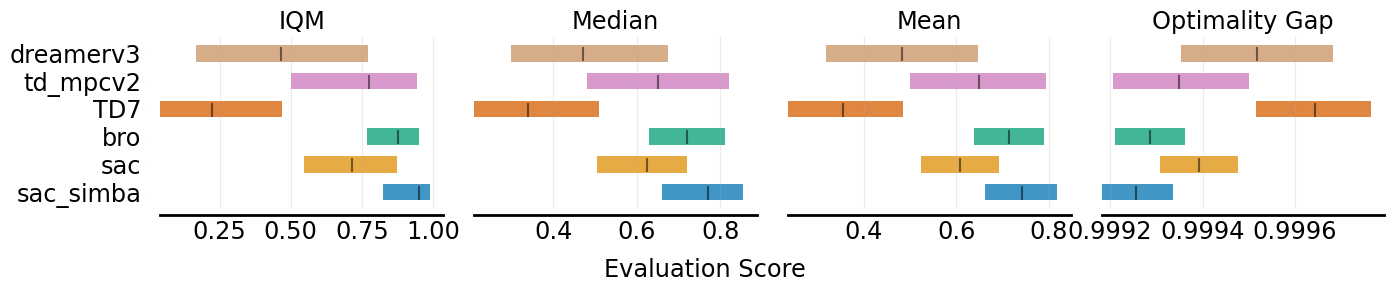

In [68]:
myo_metric_matrix_dict = generate_metric_matrix_dict(myo_eval_df, env_step=1_000_000, metric_type='avg_success')
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(
  myo_metric_matrix_dict, aggregate_func, reps=10000)

fig, axes = rly_plot_utils.plot_interval_estimates(
  aggregate_scores, aggregate_score_cis,
  metric_names=['IQM', 'Median', 'Mean', 'Optimality Gap'],
  algorithms=['sac_simba', 'sac', 'bro', 'TD7', 'td_mpcv2', 'dreamerv3'],
  xlabel_y_coordinate=-0.2,
  xlabel='Evaluation Score',
)